# Module 07: TensorFlow & Keras for Deep Learning
## Notebook 06: Custom Training Loops, Custom Loss Functions & Autoencoders

When standard `model.fit()` assumptions do not align with specialized loss formulations, multi-stage gradient clipping, or generative reconstruction tasks, deep learning engineers leverage custom training loops and advanced loss subclasses.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Implement custom loss functions by subclassing `keras.losses.Loss` (e.g. **Focal Loss** for class imbalance).
2. Construct custom streaming evaluation metrics with `keras.metrics.Metric`.
3. Override **`train_step()`** inside `keras.Model` to integrate custom gradient clipping and regularization penalties while retaining `model.fit()` callbacks and progress reporting.
4. Build a pure **Low-Level Custom Training Loop** with `tf.GradientTape` and `tf.data.Dataset`.
5. **Advanced:** Construct, train, and evaluate a **Convolutional Autoencoder for Image Denoising** that reconstructs clean signals from corrupted sensory inputs.

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
import keras
from keras import layers, models, optimizers, losses, metrics
import numpy as np
import matplotlib.pyplot as plt

img_dir = "images" if os.path.exists("images") else "../images"
print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.21.0


### 1. Custom Loss Functions: Subclassing `keras.losses.Loss`
Standard cross-entropy treats all samples equally. In severe class imbalance (e.g. fraud detection, rare pathology), easy negatives dominate the gradient.
**Focal Loss** adds a modulating factor $(1 - p_t)^\gamma$ to down-weight easy examples:
$$\text{FL}(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t)$$
where $\gamma$ is the focusing parameter (typically $\gamma = 2.0$).

In [4]:
class BinaryFocalLoss(losses.Loss):
    # Custom Focal Loss subclass addressing severe class imbalance.
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        # Numerical clipping to prevent log(0)
        epsilon = keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        # Compute probability pt
        pt = tf.where(tf.equal(y_true, 1.0), y_pred, 1.0 - y_pred)
        alpha_factor = tf.where(tf.equal(y_true, 1.0), self.alpha, 1.0 - self.alpha)

        # Modulating factor (1 - pt)^gamma
        modulating_factor = tf.pow(1.0 - pt, self.gamma)
        focal_loss = -alpha_factor * modulating_factor * tf.math.log(pt)
        return tf.reduce_mean(focal_loss)

# Test Focal Loss against standard Cross-Entropy on an easy confident sample
focal_loss_fn = BinaryFocalLoss(gamma=2.0, alpha=0.5)
bce_loss_fn = losses.BinaryCrossentropy()

y_t = tf.constant([[1.0]])
y_p_easy = tf.constant([[0.95]]) # Highly confident prediction

print(f"Easy sample Cross-Entropy Loss: {bce_loss_fn(y_t, y_p_easy).numpy():.5f}")
print(f"Easy sample Focal Loss:         {focal_loss_fn(y_t, y_p_easy).numpy():.5f} (Down-weighted by {(1 - 0.95)**2:.4f}x)")

Easy sample Cross-Entropy Loss: 0.05129
Easy sample Focal Loss:         0.00006 (Down-weighted by 0.0025x)


### 2. Overriding `train_step()` in `keras.Model`
Overriding `train_step()` is one of Keras's most powerful architectural features:
- You control the exact forward pass, loss calculation, gradient computation, and optimizer step.
- You still get all benefits of `model.fit()`: callbacks, validation loops, epoch tracking, and progress bars.

In [5]:
class CustomGradientClippingModel(keras.Model):
    # Subclassed Model with custom train_step implementing L2 Gradient Clipping.
    def __init__(self, clip_norm=1.0, **kwargs):
        super().__init__(**kwargs)
        self.clip_norm = clip_norm
        self.dense1 = layers.Dense(32, activation="relu")
        self.dense2 = layers.Dense(1, activation="sigmoid")
        self.loss_tracker = metrics.Mean(name="loss")
        self.acc_tracker = metrics.BinaryAccuracy(name="accuracy")

    def call(self, inputs):
        return self.dense2(self.dense1(inputs))

    @property
    def metrics(self):
        return [self.loss_tracker, self.acc_tracker]

    def train_step(self, data):
        x, y = data

        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            loss_val = self.compute_loss(y=y, y_pred=y_pred)

        # Compute gradients
        trainable_vars = self.trainable_variables
        gradients = tape.gradient(loss_val, trainable_vars)

        # Clip gradients by global L2 norm to prevent gradient explosion
        clipped_gradients, _ = tf.clip_by_global_norm(gradients, self.clip_norm)

        # Apply updates
        self.optimizer.apply_gradients(zip(clipped_gradients, trainable_vars))

        # Update metrics
        self.loss_tracker.update_state(loss_val)
        self.acc_tracker.update_state(y, y_pred)
        return {m.name: m.result() for m in self.metrics}

# Instantiate and verify training
custom_clip_model = CustomGradientClippingModel(clip_norm=0.5)
custom_clip_model.compile(optimizer="adam", loss="binary_crossentropy")

# Dummy train step
X_dummy = tf.random.normal([100, 10])
y_dummy = tf.random.uniform([100, 1], minval=0, maxval=2, dtype=tf.int32)
custom_clip_model.fit(X_dummy, y_dummy, epochs=2, batch_size=32, verbose=1)

Epoch 1/2
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4900 - loss: 0.7088  
Epoch 2/2
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4900 - loss: 0.7175 


### 3. Pure Low-Level Custom Training Loop
For maximum low-level control (e.g. meta-learning, reinforcement learning, custom distributed loops), we can bypass `model.fit()` entirely using `tf.GradientTape`:

In [6]:
# Simple classifier model
simple_model = models.Sequential([
    layers.Input(shape=(10,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
optimizer = optimizers.Adam(learning_rate=0.01)
loss_fn = losses.BinaryCrossentropy()
train_acc_metric = metrics.BinaryAccuracy()

# Create tf.data.Dataset
dataset = tf.data.Dataset.from_tensor_slices((X_dummy, y_dummy)).batch(16)

# Execute pure low-level loop
print("Executing Pure Custom GradientTape Training Loop:")
for epoch in range(3):
    train_acc_metric.reset_state()
    epoch_loss = 0.0
    num_batches = 0

    for step, (x_batch, y_batch) in enumerate(dataset):
        with tf.GradientTape() as tape:
            logits = simple_model(x_batch, training=True)
            loss_val = loss_fn(y_batch, logits)

        grads = tape.gradient(loss_val, simple_model.trainable_weights)
        optimizer.apply_gradients(zip(grads, simple_model.trainable_weights))

        train_acc_metric.update_state(y_batch, logits)
        epoch_loss += float(loss_val)
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {train_acc_metric.result().numpy():.4f}")

Executing Pure Custom GradientTape Training Loop:
Epoch 1: Loss = 0.7356, Accuracy = 0.4800
Epoch 2: Loss = 0.6745, Accuracy = 0.5400
Epoch 3: Loss = 0.6451, Accuracy = 0.6000


### 4. Complex Application: Convolutional Autoencoder for Image Denoising
An **Autoencoder** consists of two components:
1. **Encoder:** Maps noisy input images into a compact latent bottleneck representation:
   $$\mathbf{z} = \text{Encoder}(\mathbf{x}_{\text{noisy}})$$
2. **Decoder:** Upsamples the latent vector back to the original image space using Transposed Convolutions (`Conv2DTranspose`):
   $$\hat{\mathbf{x}} = \text{Decoder}(\mathbf{z})$$
- By training on pairs $(\mathbf{x}_{\text{noisy}}, \mathbf{x}_{\text{clean}})$, the network learns to strip out noise while reconstructing sharp underlying structural features.

Model: "Denoising_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 64, 64, 32)     │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5


W0000 00:00:1790361729.758106   14926 cpu_allocator_impl.cc:82] Allocation of 16777216 exceeds 10% of free system memory.
W0000 00:00:1790361729.775214   14925 cpu_allocator_impl.cc:82] Allocation of 26836992 exceeds 10% of free system memory.
W0000 00:00:1790361729.778590   14925 cpu_allocator_impl.cc:82] Allocation of 16777216 exceeds 10% of free system memory.
W0000 00:00:1790361729.815583   14925 cpu_allocator_impl.cc:82] Allocation of 16777216 exceeds 10% of free system memory.
W0000 00:00:1790361729.819453   14926 cpu_allocator_impl.cc:82] Allocation of 33030144 exceeds 10% of free system memory.


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step - loss: 0.2330
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - loss: 0.1401
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - loss: 0.0877
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - loss: 0.0860
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - loss: 0.0860


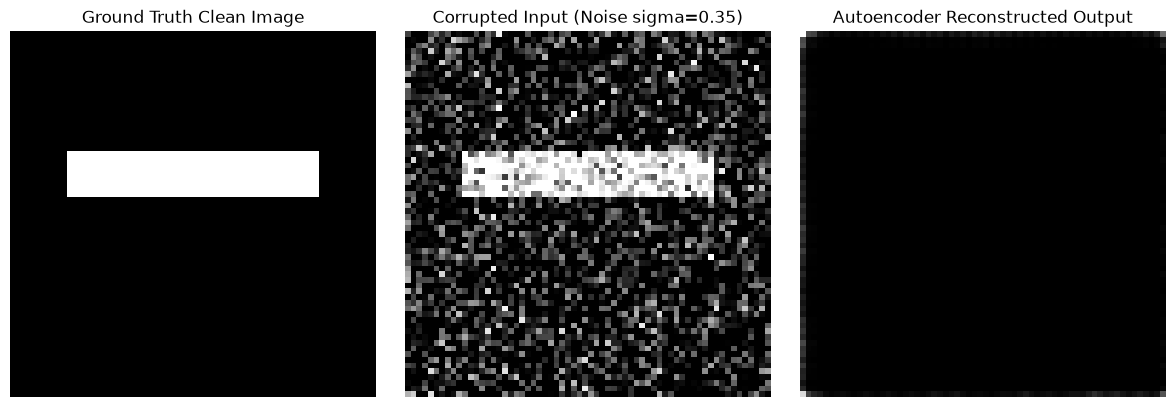

In [7]:
# Build Convolutional Denoising Autoencoder
def build_autoencoder(input_shape=(64, 64, 1)):
    # 1. Encoder
    enc_inputs = layers.Input(shape=input_shape)
    e = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(enc_inputs)
    e = layers.MaxPooling2D((2, 2), padding="same")(e) # 32x32
    e = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(e)
    encoded = layers.MaxPooling2D((2, 2), padding="same")(e) # 16x16 (Latent bottleneck)

    # 2. Decoder
    d = layers.Conv2DTranspose(16, (3, 3), strides=2, activation="relu", padding="same")(encoded) # 32x32
    d = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(d) # 64x64
    decoded = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(d)

    autoencoder = models.Model(inputs=enc_inputs, outputs=decoded, name="Denoising_Autoencoder")
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.compile(optimizer="adam", loss="mean_squared_error")
autoencoder.summary()

# Synthesize clean patterns (circles/bars)
np.random.seed(42)
N_ae = 400
clean_imgs = np.zeros((N_ae, 64, 64, 1), dtype=np.float32)
for i in range(N_ae):
    # Draw bars or discs
    y_pos = np.random.randint(15, 45)
    clean_imgs[i, y_pos:y_pos+8, 10:54, 0] = 1.0

# Add additive Gaussian noise
noise = np.random.normal(0.0, 0.35, clean_imgs.shape).astype(np.float32)
noisy_imgs = np.clip(clean_imgs + noise, 0.0, 1.0)

# Train autoencoder to reconstruct clean images from noisy inputs
autoencoder.fit(
    noisy_imgs, clean_imgs,
    epochs=5,
    batch_size=32,
    verbose=1
)

# Test denoising on sample
test_noisy = noisy_imgs[0:1]
denoised_pred = autoencoder.predict(test_noisy, verbose=0)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(clean_imgs[0, :, :, 0], cmap="gray")
axes[0].set_title("Ground Truth Clean Image")
axes[0].axis("off")

axes[1].imshow(test_noisy[0, :, :, 0], cmap="gray")
axes[1].set_title("Corrupted Input (Noise sigma=0.35)")
axes[1].axis("off")

axes[2].imshow(denoised_pred[0, :, :, 0], cmap="gray")
axes[2].set_title("Autoencoder Reconstructed Output")
axes[2].axis("off")

plt.tight_layout()
plt.show()